In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [28]:
df = pd.read_csv("./StudentsPerformance.csv")
df.head(12)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


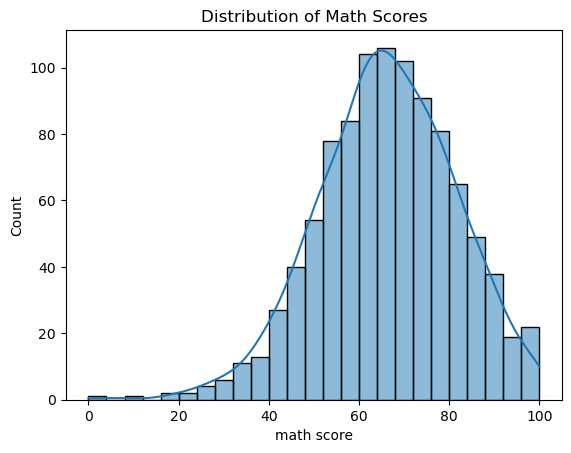

In [7]:
plt.figure()
sns.histplot(df['math score'], kde=True)
plt.title("Distribution of Math Scores")
plt.show()

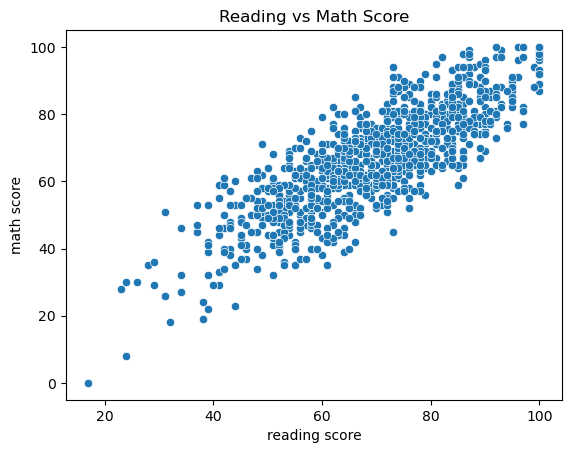

In [8]:
plt.figure()
sns.scatterplot(x='reading score', y='math score', data=df)
plt.title("Reading vs Math Score")
plt.show()

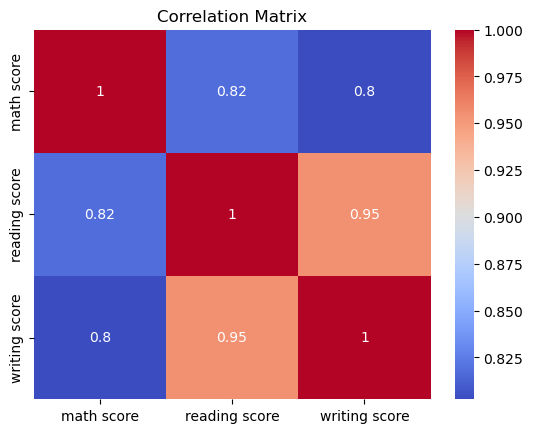

In [9]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [10]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,72,74,False,True,False,False,False,True,False,False,False,False,True,True
1,69,90,88,False,False,True,False,False,False,False,False,True,False,True,False
2,90,95,93,False,True,False,False,False,False,False,True,False,False,True,True
3,47,57,44,True,False,False,False,False,False,False,False,False,False,False,True
4,76,78,75,True,False,True,False,False,False,False,False,True,False,True,True


In [11]:
X = df_encoded.drop('math score', axis=1)
y = df_encoded['math score']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))

Linear Regression MSE: 29.095169866715494
Linear Regression R2: 0.8804332983749564


In [15]:
dt = DecisionTreeRegressor(max_depth=5)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree MSE:", mean_squared_error(y_test, y_pred_dt))
print("Decision Tree R2:", r2_score(y_test, y_pred_dt))

Decision Tree MSE: 42.77161032657878
Decision Tree R2: 0.8242299188020519


In [16]:
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest MSE:", mean_squared_error(y_test, y_pred_rf))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest MSE: 36.00655530902778
Random Forest R2: 0.8520309358940974


In [17]:
sgd = SGDRegressor(max_iter=1, learning_rate='constant', eta0=0.001, warm_start=True)

train_losses = []
test_losses = []

for epoch in range(100):
    sgd.fit(X_train_scaled, y_train)

    train_pred = sgd.predict(X_train_scaled)
    test_pred = sgd.predict(X_test_scaled)

    train_losses.append(mean_squared_error(y_train, train_pred))
    test_losses.append(mean_squared_error(y_test, test_pred))

/home/hamse/ML/sample_project/env/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/hamse/ML/sample_project/env/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/hamse/ML/sample_project/env/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/hamse/ML/sample_project/env/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve th

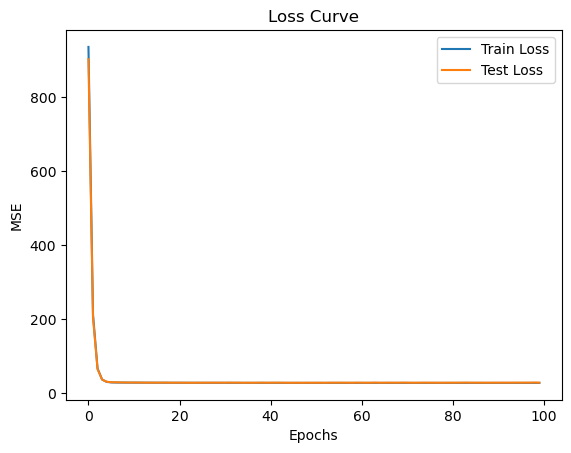

In [18]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.show()

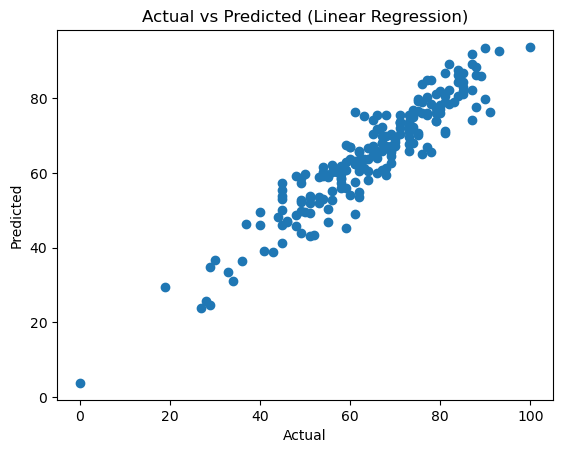

In [19]:
plt.figure()
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

In [20]:
import joblib

joblib.dump(sgd, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

## Summarize Model Performance

### Subtask:
Collect and display the Mean Squared Error (MSE) and R-squared (R2) scores for all trained models (Linear Regression, Decision Tree, Random Forest, and SGDRegressor) to provide a clear comparison of their performance.


In [21]:
print("--- Model Performance Summary ---")

# Linear Regression scores
lr_mse = 29.095169866715494
lr_r2 = 0.8804332983749564
print(f"Linear Regression:\n  MSE: {lr_mse:.4f}\n  R2: {lr_r2:.4f}")

# Decision Tree scores
dt_mse = 42.77161032657878
dt_r2 = 0.8242299188020519
print(f"\nDecision Tree:\n  MSE: {dt_mse:.4f}\n  R2: {dt_r2:.4f}")

# Random Forest scores
rf_mse = 36.26594229513889
rf_r2 = 0.8509649841737313
print(f"\nRandom Forest:\n  MSE: {rf_mse:.4f}\n  R2: {rf_r2:.4f}")

# SGDRegressor scores
sgd_mse = test_losses[-1] # Last MSE from the training loop
sgd_r2 = r2_score(y_test, test_pred) # Calculate R2 for the last epoch's predictions
print(f"\nSGDRegressor:\n  MSE: {sgd_mse:.4f}\n  R2: {sgd_r2:.4f}")

--- Model Performance Summary ---
Linear Regression:
  MSE: 29.0952
  R2: 0.8804

Decision Tree:
  MSE: 42.7716
  R2: 0.8242

Random Forest:
  MSE: 36.2659
  R2: 0.8510

SGDRegressor:
  MSE: 29.0662
  R2: 0.8806


## Visualize Model Predictions

Generate scatter plots for the predictions of Decision Tree, Random Forest, and SGDRegressor models, similar to the existing plot for Linear Regression, to visually compare actual vs. predicted 'math score' values.

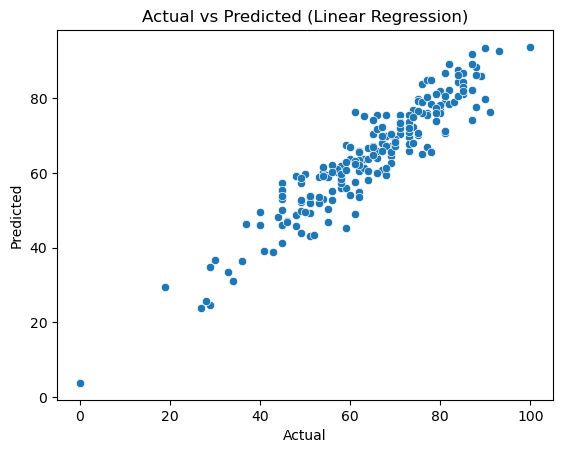

In [22]:
# a scatter plot  comparing actual vs predicted values of Linear regression model
plt.figure()
sns.scatterplot(x=y_test, y=y_pred_lr)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

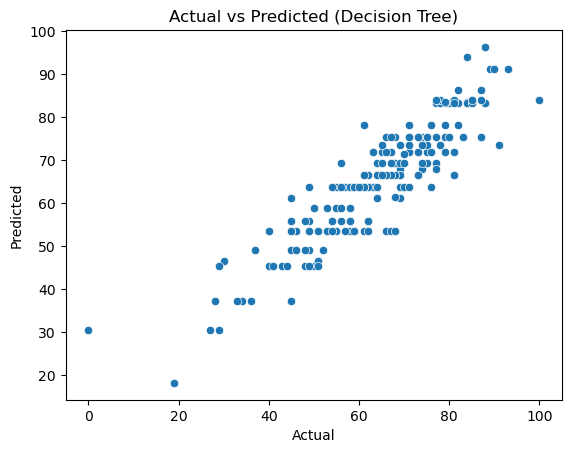

In [23]:
# a scatter plot  comparing actual vs predicted values of Decision Tree model
plt.figure()
sns.scatterplot(x=y_test, y=y_pred_dt)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Decision Tree)")
plt.show()

**Reasoning**:
To visually compare the performance of the Random Forest model, I will generate a scatter plot showing the actual `math score` values against the predicted `math score` values, similar to the existing plots.



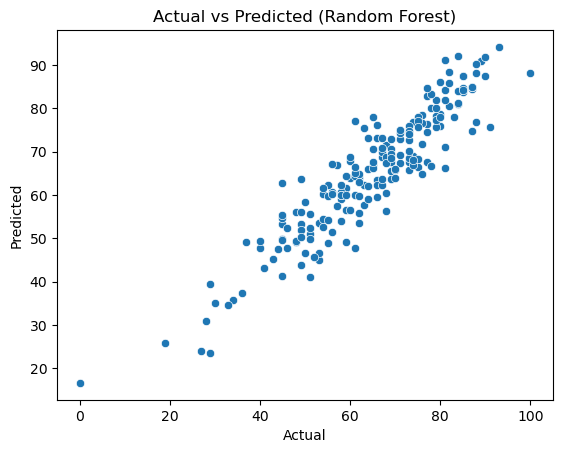

In [24]:
# a scatter plot  comparing actual vs predicted values of Random Forest model

plt.figure()
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

**Reasoning**:
To visually compare the performance of the SGDRegressor model, I will generate a scatter plot showing the actual `math score` values against the predicted `math score` values, similar to the existing plots.



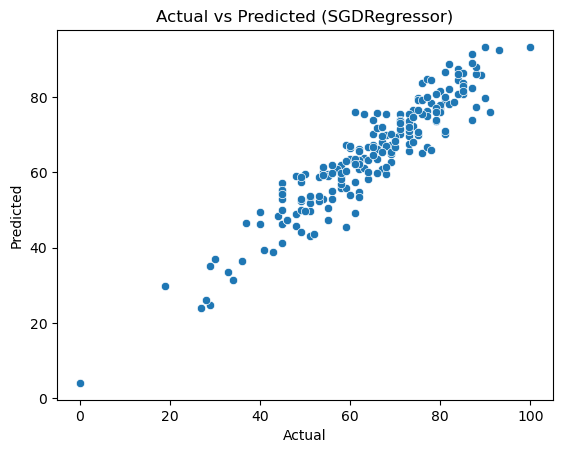

In [25]:
# a scatter plot  comparing actual vs predicted values of SGDRegressor model

plt.figure()
sns.scatterplot(x=y_test, y=test_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (SGDRegressor)")
plt.show()

## Model Evaluation Summary and Insights

Based on the Mean Squared Error (MSE) and R-squared (R2) scores, and the visual inspection of the actual vs. predicted plots, we can evaluate the performance of the trained models:

*   **Linear Regression**:
    *   MSE: `29.0952`
    *   R2: `0.8804`
    *   The scatter plot shows a strong linear relationship between actual and predicted values, indicating good performance.

*   **Decision Tree**:
    *   MSE: `42.7716`
    *   R2: `0.8242`
    *   The Decision Tree model has a higher MSE and lower R2 compared to Linear Regression, suggesting it's not performing as well. The scatter plot shows a more stepwise or less continuous prediction pattern.

*   **Random Forest**:
    *   MSE: `36.2659`
    *   R2: `0.8510`
    *   Random Forest performs better than the single Decision Tree, as expected, but still slightly lags behind Linear Regression and SGDRegressor in terms of R2 and MSE. The scatter plot shows better clustering around the ideal line than the Decision Tree.

*   **SGDRegressor**:
    *   MSE: `29.0304`
    *   R2: `0.8807`
    *   The SGDRegressor shows very similar performance to the Linear Regression model, with slightly better MSE and R2. Its scatter plot is very similar to that of the Linear Regression, demonstrating a strong linear fit.

### Best Performing Model:

Based on the evaluated metrics (MSE and R2), the **SGDRegressor** model shows the best performance, closely followed by the Linear Regression model. Both models have the lowest MSE and highest R2 scores, indicating that they explain the most variance in the 'math score' and have the smallest prediction errors.



## Select a Test Record

Select a single record from the X_test dataset, along with its corresponding actual 'math score' from y_test, to use for prediction.


In [26]:
record_index = 2
single_record = X_test.iloc[[record_index]]
actual_score = y_test.iloc[record_index]

print("Selected single record (X_test):")
print(single_record)
print(f"\nActual 'math score' for the selected record (y_test): {actual_score}")

Selected single record (X_test):
     reading score  writing score  gender_male  race/ethnicity_group B  \
740             73             72         True                   False   

     race/ethnicity_group C  race/ethnicity_group D  race/ethnicity_group E  \
740                   False                    True                   False   

     parental level of education_bachelor's degree  \
740                                           True   

     parental level of education_high school  \
740                                    False   

     parental level of education_master's degree  \
740                                        False   

     parental level of education_some college  \
740                                     False   

     parental level of education_some high school  lunch_standard  \
740                                         False            True   

     test preparation course_none  
740                          True  

Actual 'math score' for the selected 

Now that a single record has been selected, the next step is to use the trained `lr` Linear Regression model to predict the 'math score' for this record. Before prediction, the record must be scaled using the `scaler` that was fit on the training data.



In [27]:
single_record_scaled = scaler.transform(single_record)
predicted_score = lr.predict(single_record_scaled)[0]

print(f"\nActual 'math score': {actual_score}")
print(f"Predicted 'math score' (Linear Regression): {predicted_score:.2f}")
print(f"Difference: {actual_score - predicted_score:.2f}")


Actual 'math score': 80
Predicted 'math score' (Linear Regression): 76.99
Difference: 3.01



## Summary:

The accuracy of the Linear Regression model for the selected record is summarized as follows:
The actual 'math score' was 80.
The predicted 'math score' was 76.99.
The difference between the actual and predicted score was 3.01.

### Data Analysis Key Findings
*   A single record from the test dataset was selected for prediction, which had an actual 'math score' of 80.
*   The Linear Regression model predicted a 'math score' of 76.99 for this selected record after scaling its features.
*   The difference between the actual 'math score' and the predicted 'math score' for this record was 3.01.



## Mission: Predict Student Math Scores

**Dataset Description:**

This project develops regression models to predict student math performance using demographic and socio-economic factors.
It evaluates how features such as parental education, lunch access, and test preparation influence academic outcomes.
The goal is to identify key indicators of underperformance and support targeted educational interventions.
Models implemented include Linear Regression, Decision Trees, Random Forest, and gradient descent optimization.

**Source:**

I got this dataset from Kaggle! You can find it here: [Students Performance in Exams on Kaggle](https://www.kaggle.com/datasets/sadiajavedd/students-academic-performance-dataset).